# c-PSD / Pore Size Distribution Analysis

このNotebookでは、3D SEM / FIB-SEM由来の3D TIFF画像から作成した孔相マスクを用いて、孔径分布を評価します。前回のNotebookでは、全体空隙率と方向別空隙率を計算しました。今回は、空隙の「量」だけでなく、「孔の大きさ分布」を評価します。

参考論文では、c-PSD法により3D空隙内に入る球の半径から孔径分布を推定しています。本Notebookでは、この考え方をPythonで扱いやすい形にし、距離変換、local thickness、および最大球 / centroid pathに基づくstrict c-PSD近似を用いて孔径分布を計算します。

**重要:** 距離変換 / local thicknessは簡易近似です。後半のstrict c-PSDセクションでは、最大球候補、最大球による孔相被覆、centroid path上の最小半径を追加で計算します。ただし、論文実装の完全再現ではなく、画像解析用の再現可能な近似実装として扱ってください。


## 1. ライブラリ読み込み

`porespy`はoptionalです。インストールされていない場合でも、scipyの距離変換による基本解析は実行できます。


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
from scipy.ndimage import median_filter, distance_transform_edt, zoom, maximum_filter, label
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes

try:
    import porespy as ps
    HAS_PORESPY = True
except ImportError:
    HAS_PORESPY = False
    print("porespy is not installed. The notebook will run with scipy distance transform only.")


## 2. パラメータ設定

voxel sizeは孔径をµm単位で評価するために必須です。異方性voxelに対応するため、距離変換では `sampling=(VOXEL_SIZE_Z, VOXEL_SIZE_Y, VOXEL_SIZE_X)` を使用します。


In [2]:
INPUT_TIF = "data/Targray_PE16A/Targray_PE16A_1200x700x500_10nmVoxelSize.tif"
OUTPUT_DIR = "outputs/cpsd_output"

# ファイル名の通り、このデータは孔が白いので False にします。
PORE_IS_DARK = True

# 入力画像はすでに 0/255 の二値画像なので、デフォルトではフィルタをかけません。
USE_MEDIAN_FILTER = False
MEDIAN_SIZE = 2
USE_MANUAL_THRESHOLD = False
MANUAL_THRESHOLD = 128

# voxel size
# 単位は µm
VOXEL_SIZE_Z = 0.02
VOXEL_SIZE_Y = 0.01
VOXEL_SIZE_X = 0.01

# 3D距離変換はメモリ使用量が大きいため、CPSD計算用に間引きます。
# 1: 元解像度、2: 各方向1/2、4: 各方向1/4、8: 各方向1/8
EDT_STRIDE = 8

# PSD bin設定
RADIUS_BIN_WIDTH_UM = 0.01
MIN_RADIUS_UM = 0.0
MAX_RADIUS_UM = None

# strict c-PSD近似設定
# 最大球候補を抽出し、大きい球から孔相を被覆してPSDを計算します。
RUN_STRICT_CPSD = True
STRICT_MIN_RADIUS_UM = None  # Noneの場合、距離変換voxel samplingの最小値を使用
STRICT_MAX_SPHERES = 2000    # 計算時間を抑えるため、半径の大きい候補から上限数だけ使う
STRICT_LOCAL_MAX_SIZE = 3    # 局所最大判定の近傍サイズ。通常は3でよい
STRICT_PATH_MAX_STEPS = 300   # centroid pathをサンプリングする最大点数

# 小さいノイズ孔や穴埋め（孔構造を勝手に変えないため、デフォルトではOFF）
REMOVE_SMALL_OBJECTS = False
MIN_OBJECT_SIZE = 64
REMOVE_SMALL_HOLES_FLAG = False
MIN_HOLE_SIZE = 64

project_root = Path.cwd()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent

input_path = Path(INPUT_TIF)
if not input_path.is_absolute():
    input_path = project_root / input_path
INPUT_TIF = str(input_path)

output_dir = Path(OUTPUT_DIR)
if not output_dir.is_absolute():
    output_dir = project_root / output_dir
output_dir.mkdir(parents=True, exist_ok=True)


## 3. 3D TIFF読み込み、前処理、二値化

TIFFを読み込み、中央スライス、輝度範囲、二値化結果を確認します。`PORE_IS_DARK = True` の場合は低輝度側を孔相、`False` の場合は高輝度側を孔相として扱います。


shape: (500, 700, 1200)
dtype: uint8
min: 0
max: 255


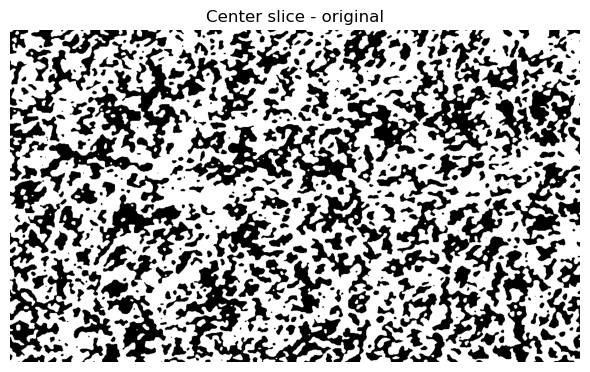

In [3]:
img = tiff.imread(INPUT_TIF)
print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", np.min(img))
print("max:", np.max(img))

z_mid = img.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(img[z_mid], cmap="gray")
plt.title("Center slice - original")
plt.axis("off")
plt.tight_layout()
plt.savefig(output_dir / "center_slice_original.png", dpi=200)
plt.show()


binary image detected; adjusted threshold to midpoint: 127.5
threshold: 127.5
porosity: 0.409862 (40.99 %)


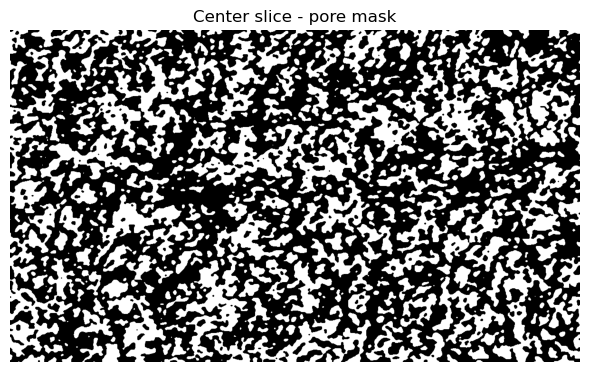

In [4]:
if USE_MEDIAN_FILTER:
    img_filt = median_filter(img, size=MEDIAN_SIZE)
else:
    img_filt = img.copy()

if USE_MANUAL_THRESHOLD:
    threshold = MANUAL_THRESHOLD
else:
    threshold = threshold_otsu(img_filt)

# 0/255などの二値画像では、Otsuしきい値が最小値そのものになる場合があります。
# そのまま pore = image < 0 とすると、黒い孔(0)も除外されるため、二値画像では中間値を使います。
unique_values = np.unique(img_filt)
if unique_values.size == 2 and (threshold <= unique_values.min() or threshold >= unique_values.max()):
    threshold = 0.5 * (float(unique_values.min()) + float(unique_values.max()))
    print("binary image detected; adjusted threshold to midpoint:", threshold)

print("threshold:", threshold)

if PORE_IS_DARK:
    pore = img_filt < threshold
else:
    pore = img_filt > threshold

if REMOVE_SMALL_OBJECTS:
    pore = remove_small_objects(pore, min_size=MIN_OBJECT_SIZE)

if REMOVE_SMALL_HOLES_FLAG:
    pore = remove_small_holes(pore, area_threshold=MIN_HOLE_SIZE)

solid = ~pore
porosity = pore.mean()
print(f"porosity: {porosity:.6f} ({porosity * 100:.2f} %)")

plt.figure(figsize=(6, 6))
plt.imshow(pore[z_mid], cmap="gray")
plt.title("Center slice - pore mask")
plt.axis("off")
plt.tight_layout()
plt.savefig(output_dir / "center_slice_pore_mask.png", dpi=200)
plt.show()


## 4. 距離変換による基本的な孔径分布

孔相に対して3D距離変換を実施します。`distance_um` は、各孔ボクセルが固体/孔界面からどれだけ離れているかを表す局所半径です。単位はµmです。

**注意:** これは厳密なc-PSDではなく、距離変換に基づく「局所半径分布」です。Münch and Holzerのc-PSD法を参考にした近似実装として解釈してください。


In [5]:
if not np.any(pore):
    raise ValueError(
        "No pore voxels were detected. Check PORE_IS_DARK and the threshold settings. "
        f"Current threshold={threshold}, PORE_IS_DARK={PORE_IS_DARK}."
    )

pore_for_edt = pore[::EDT_STRIDE, ::EDT_STRIDE, ::EDT_STRIDE]
sampling_for_edt = (
    VOXEL_SIZE_Z * EDT_STRIDE,
    VOXEL_SIZE_Y * EDT_STRIDE,
    VOXEL_SIZE_X * EDT_STRIDE,
)

print("EDT input shape:", pore_for_edt.shape)
print("EDT voxel sampling [um]:", sampling_for_edt)

distance_um = distance_transform_edt(
    pore_for_edt,
    sampling=sampling_for_edt
)

radius_values_um = distance_um[pore_for_edt]
diameter_values_um = 2 * radius_values_um

print("number of pore voxels used for EDT:", radius_values_um.size)
print("max radius [um]:", np.nanmax(radius_values_um))


EDT input shape: (63, 88, 150)
EDT voxel sampling [um]: (0.16, 0.08, 0.08)
number of pore voxels used for EDT: 341433
max radius [um]: 0.2262741699796952


## 5. ヒストグラムPSDの計算

半径分布と直径分布をヒストグラム化し、各binの孔体積割合および累積孔体積割合を計算します。


In [6]:
if MAX_RADIUS_UM is None:
    max_radius = np.nanmax(radius_values_um)
else:
    max_radius = MAX_RADIUS_UM

bins_radius = np.arange(MIN_RADIUS_UM, max_radius + RADIUS_BIN_WIDTH_UM, RADIUS_BIN_WIDTH_UM)
hist_radius, edges_radius = np.histogram(radius_values_um, bins=bins_radius)
volume_fraction = hist_radius / hist_radius.sum()
cumulative_volume_fraction = np.cumsum(volume_fraction)
radius_center_um = 0.5 * (edges_radius[:-1] + edges_radius[1:])
diameter_center_um = 2 * radius_center_um

psd_df = pd.DataFrame({
    "radius_um": radius_center_um,
    "diameter_um": diameter_center_um,
    "voxel_count": hist_radius,
    "volume_fraction": volume_fraction,
    "cumulative_volume_fraction": cumulative_volume_fraction
})

psd_df.to_csv(output_dir / "distance_transform_psd.csv", index=False)
psd_df.head()


,radius_um,diameter_um,voxel_count,volume_fraction,cumulative_volume_fraction
0,0.005,0.01,0,0.0,0.0
1,0.015,0.03,0,0.0,0.0
2,0.025,0.05,0,0.0,0.0
3,0.035,0.07,0,0.0,0.0
4,0.045,0.09,0,0.0,0.0


## 6. 代表値の計算

以下の代表値は、孔相ボクセルを母集団とした空隙体積加重平均・分位点です。つまり、孔相体積に占める各局所半径の寄与に基づく値であり、個々の独立孔を数えた個数平均ではありません。


In [7]:
mean_radius_um = float(np.mean(radius_values_um))
median_radius_um = float(np.median(radius_values_um))
p10_radius_um, p50_radius_um, p90_radius_um = [float(v) for v in np.percentile(radius_values_um, [10, 50, 90])]

mean_diameter_um = float(np.mean(diameter_values_um))
median_diameter_um = float(np.median(diameter_values_um))
p10_diameter_um, p50_diameter_um, p90_diameter_um = [float(v) for v in np.percentile(diameter_values_um, [10, 50, 90])]

summary_df = pd.DataFrame([{
    "input_file": INPUT_TIF,
    "shape_z": img.shape[0],
    "shape_y": img.shape[1],
    "shape_x": img.shape[2],
    "voxel_size_z_um": VOXEL_SIZE_Z,
    "voxel_size_y_um": VOXEL_SIZE_Y,
    "voxel_size_x_um": VOXEL_SIZE_X,
    "threshold": threshold,
    "pore_is_dark": PORE_IS_DARK,
    "porosity": porosity,
    "mean_radius_um": mean_radius_um,
    "median_radius_um": median_radius_um,
    "p10_radius_um": p10_radius_um,
    "p50_radius_um": p50_radius_um,
    "p90_radius_um": p90_radius_um,
    "mean_diameter_um": mean_diameter_um,
    "median_diameter_um": median_diameter_um,
    "p10_diameter_um": p10_diameter_um,
    "p50_diameter_um": p50_diameter_um,
    "p90_diameter_um": p90_diameter_um,
    "method": "distance_transform_edt",
    "notes": "Distance-transform-based pore radius distribution; inspired by c-PSD but not identical to the original Munch-Holzer implementation."
}])
summary_df.to_csv(output_dir / "cpsd_summary.csv", index=False)
summary_df


,input_file,shape_z,shape_y,shape_x,voxel_size_z_um,voxel_size_y_um,voxel_size_x_um,threshold,pore_is_dark,porosity,...,p10_radius_um,p50_radius_um,p90_radius_um,mean_diameter_um,median_diameter_um,p10_diameter_um,p50_diameter_um,p90_diameter_um,method,notes
0,c:\Users\natsu_ocw5fqu\Documents\pore-structur...,500,700,1200,0.02,0.01,0.01,127.5,True,0.409862,...,0.08,0.08,0.113137,0.169954,0.16,0.16,0.16,0.226274,distance_transform_edt,Distance-transform-based pore radius distribut...


## 7. グラフ出力

半径分布、直径分布、累積孔径分布を保存します。参考論文のFig. 4のように、体積分率および累積体積分率として孔径分布を確認できます。


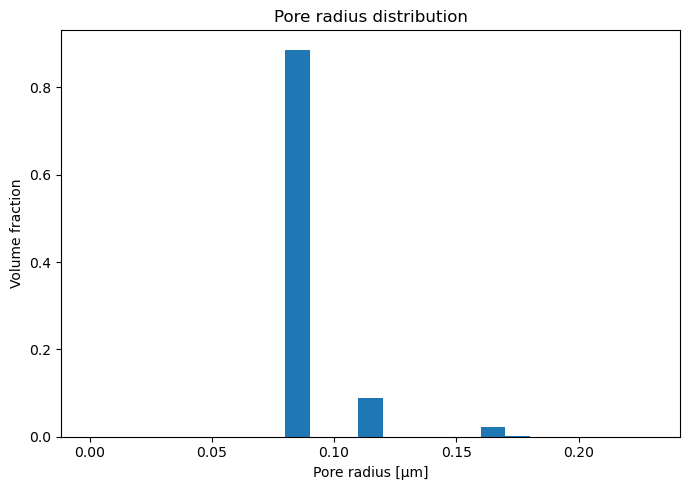

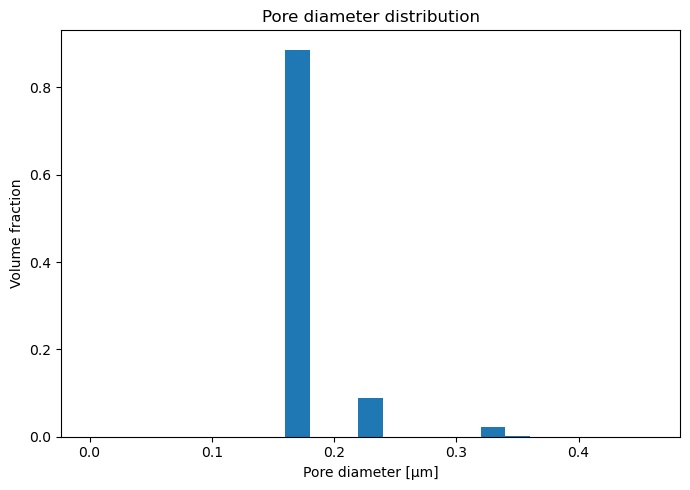

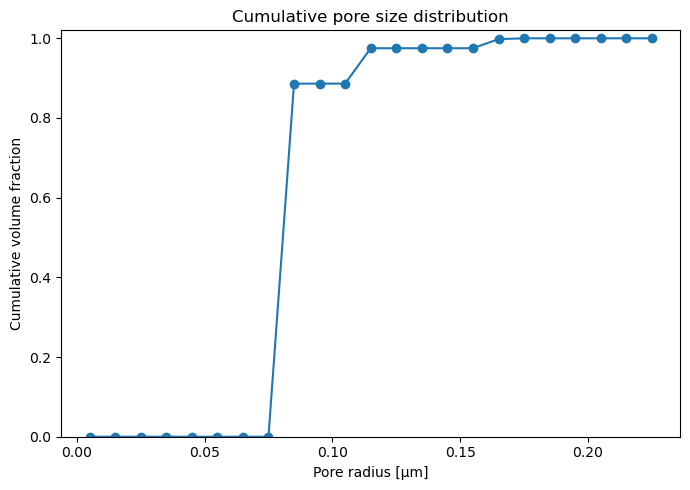

In [8]:
plt.figure(figsize=(7, 5))
plt.bar(psd_df["radius_um"], psd_df["volume_fraction"], width=RADIUS_BIN_WIDTH_UM, align="center")
plt.xlabel("Pore radius [µm]")
plt.ylabel("Volume fraction")
plt.title("Pore radius distribution")
plt.tight_layout()
plt.savefig(output_dir / "pore_radius_distribution.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(psd_df["diameter_um"], psd_df["volume_fraction"], width=2 * RADIUS_BIN_WIDTH_UM, align="center")
plt.xlabel("Pore diameter [µm]")
plt.ylabel("Volume fraction")
plt.title("Pore diameter distribution")
plt.tight_layout()
plt.savefig(output_dir / "pore_diameter_distribution.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(psd_df["radius_um"], psd_df["cumulative_volume_fraction"], marker="o")
plt.xlabel("Pore radius [µm]")
plt.ylabel("Cumulative volume fraction")
plt.ylim(0, 1.02)
plt.title("Cumulative pore size distribution")
plt.tight_layout()
plt.savefig(output_dir / "cumulative_pore_size_distribution.png", dpi=200)
plt.show()


## 8. カラーマップ可視化

中央スライスに対して、距離変換で得られた局所半径を孔相のみカラーマップ表示します。大きな孔がどの領域に存在するかを直感的に確認できます。


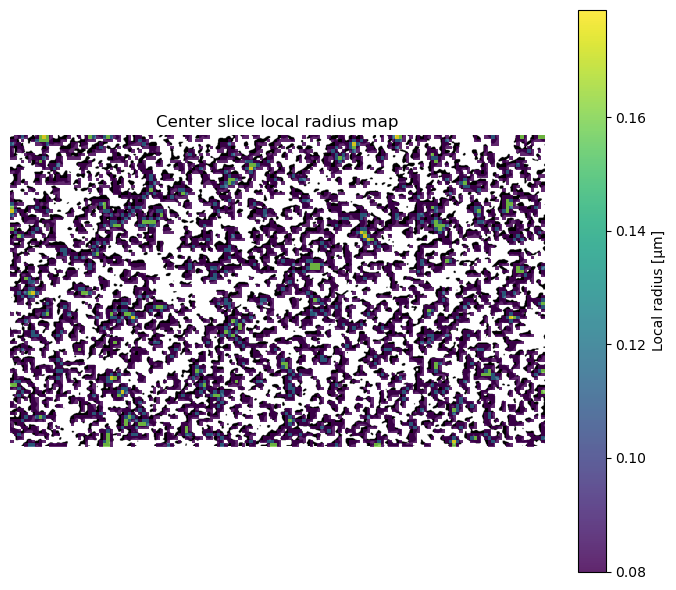

In [9]:
z_mid_edt = pore_for_edt.shape[0] // 2
z_mid_img = min(z_mid_edt * EDT_STRIDE, img.shape[0] - 1)
radius_slice = np.where(pore_for_edt[z_mid_edt], distance_um[z_mid_edt], np.nan)

plt.figure(figsize=(7, 6))
plt.imshow(img[z_mid_img], cmap="gray")
im = plt.imshow(radius_slice, cmap="viridis", alpha=0.85, extent=(0, img.shape[2], img.shape[1], 0))
plt.colorbar(im, label="Local radius [µm]")
plt.title("Center slice local radius map")
plt.axis("off")
plt.tight_layout()
plt.savefig(output_dir / "center_slice_local_radius_map.png", dpi=200)
plt.show()


## 9. optional: PoreSpy local thicknessによるc-PSD近似

`HAS_PORESPY = True` の場合のみ、`porespy.filters.local_thickness` を使ってlocal thickness解析を実施します。これは単純な距離変換ではなく、最大内接球に近い考え方で孔径分布を評価するための近似です。

注意点:
- PoreSpy local_thicknessはvoxel単位の等方voxelを前提にする場合があります。
- voxel sizeがZとXYで異なる場合は、前処理で等方voxelへリサンプリングする方が望ましいです。
- 本Notebookでは、まず簡易実装として `min(voxel size)` による換算または等方voxel前提で実施します。
- 厳密にやる場合は、画像を等方voxelにリサンプリングしてからlocal thicknessを実行してください。


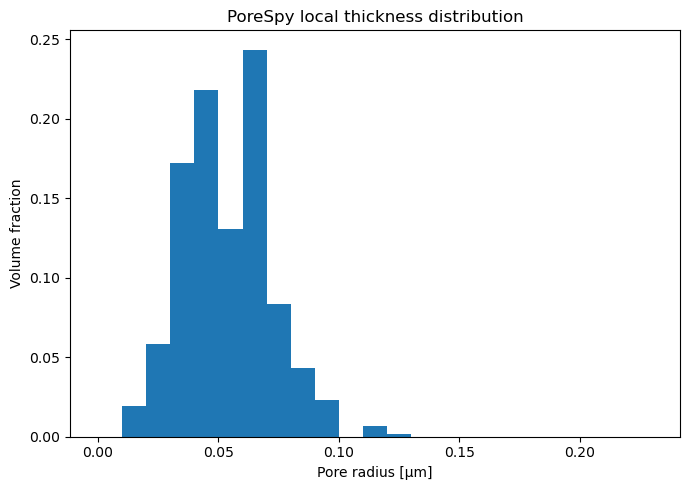

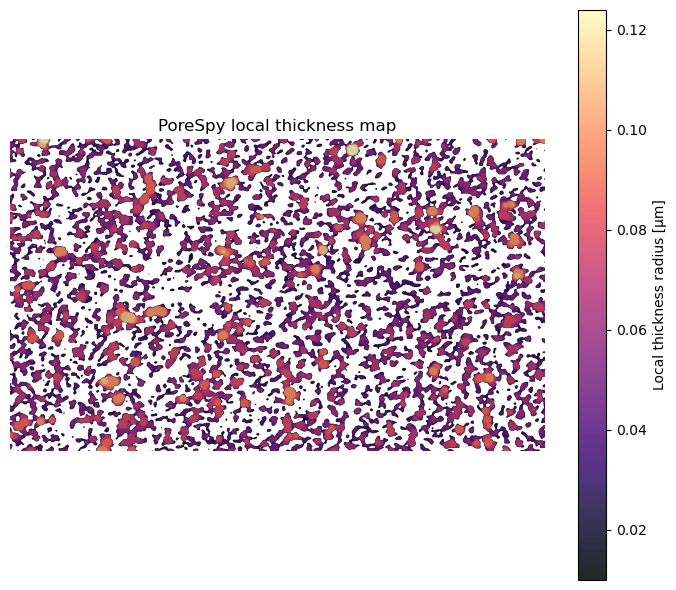

In [10]:
if HAS_PORESPY:
    try:
        lt = ps.filters.local_thickness(pore)
        lt_radius_um = lt[pore] * min(VOXEL_SIZE_Z, VOXEL_SIZE_Y, VOXEL_SIZE_X)

        lt_hist, lt_edges = np.histogram(lt_radius_um, bins=bins_radius)
        lt_volume_fraction = lt_hist / lt_hist.sum()
        lt_cumulative = np.cumsum(lt_volume_fraction)
        lt_radius_center_um = 0.5 * (lt_edges[:-1] + lt_edges[1:])

        lt_df = pd.DataFrame({
            "radius_um": lt_radius_center_um,
            "diameter_um": 2 * lt_radius_center_um,
            "voxel_count": lt_hist,
            "volume_fraction": lt_volume_fraction,
            "cumulative_volume_fraction": lt_cumulative
        })
        lt_df.to_csv(output_dir / "porespy_local_thickness_distribution.csv", index=False)

        plt.figure(figsize=(7, 5))
        plt.bar(lt_df["radius_um"], lt_df["volume_fraction"], width=RADIUS_BIN_WIDTH_UM, align="center")
        plt.xlabel("Pore radius [µm]")
        plt.ylabel("Volume fraction")
        plt.title("PoreSpy local thickness distribution")
        plt.tight_layout()
        plt.savefig(output_dir / "porespy_local_thickness_distribution.png", dpi=200)
        plt.show()

        lt_slice = np.where(pore[z_mid], lt[z_mid] * min(VOXEL_SIZE_Z, VOXEL_SIZE_Y, VOXEL_SIZE_X), np.nan)
        plt.figure(figsize=(7, 6))
        plt.imshow(img[z_mid], cmap="gray")
        im = plt.imshow(lt_slice, cmap="magma", alpha=0.85)
        plt.colorbar(im, label="Local thickness radius [µm]")
        plt.title("PoreSpy local thickness map")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(output_dir / "porespy_local_thickness_map.png", dpi=200)
        plt.show()
    except Exception as e:
        print("PoreSpy local_thickness failed:", e)
else:
    print("PoreSpy local_thickness skipped because porespy is not installed.")


## 10. 等方voxelへのリサンプリング関数

異方性voxelを等方voxelへリサンプリングするための関数です。デフォルトでは実行しません。PoreSpy local thicknessを厳密に扱いたい場合や、Z方向とXY方向のvoxel sizeが大きく異なる場合に検討してください。


In [11]:
def resample_to_isotropic(binary_volume, voxel_size_zyx, target_voxel_size=None):
    """
    binary_volume: 3D boolean array, shape = (Z, Y, X)
    voxel_size_zyx: tuple of voxel sizes in µm, (z, y, x)
    target_voxel_size: target isotropic voxel size in µm.
                       If None, use min(voxel_size_zyx).
    """
    if target_voxel_size is None:
        target_voxel_size = min(voxel_size_zyx)

    zoom_factors = tuple(v / target_voxel_size for v in voxel_size_zyx)
    resampled = zoom(binary_volume.astype(np.uint8), zoom=zoom_factors, order=0).astype(bool)
    return resampled, target_voxel_size


## 11. strict c-PSD近似: 最大球とcentroid path

このセクションでは、距離変換マップの局所最大を最大内接球の中心候補として抽出します。次に、半径の大きい最大球から順に孔相を被覆し、各半径の球がどれだけの孔体積を代表するかを集計します。

さらに、最大球中心同士を大きい球側へ結ぶcentroid pathを作り、その経路上の距離変換値の最小値を、孔のくびれに近い指標として保存します。

**注意:** これはMünch and Holzer型c-PSDの考え方に近づけるための実装ですが、論文コードの完全再現ではありません。特にcentroid pathの接続規則とconstrictivity評価は、ここでは再現可能な近似として実装しています。


In [12]:
def extract_maximal_sphere_candidates(distance_map, pore_mask, sampling_zyx, min_radius_um=None, max_spheres=None, local_max_size=3):
    """Extract local maxima of the EDT as maximal-sphere center candidates."""
    if min_radius_um is None:
        min_radius_um = min(sampling_zyx)

    local_max = maximum_filter(distance_map, size=local_max_size) == distance_map
    maxima_mask = pore_mask & local_max & (distance_map >= min_radius_um)
    labels, num_labels = label(maxima_mask)

    records = []
    for label_id in range(1, num_labels + 1):
        pts = np.argwhere(labels == label_id)
        if pts.size == 0:
            continue
        radii = distance_map[tuple(pts.T)]
        best = pts[int(np.argmax(radii))]
        radius_um = float(distance_map[tuple(best)])
        records.append({
            "sphere_id": len(records),
            "z_index": int(best[0]),
            "y_index": int(best[1]),
            "x_index": int(best[2]),
            "z_um": float(best[0] * sampling_zyx[0]),
            "y_um": float(best[1] * sampling_zyx[1]),
            "x_um": float(best[2] * sampling_zyx[2]),
            "radius_um": radius_um,
            "diameter_um": 2.0 * radius_um,
            "plateau_voxel_count": int(len(pts)),
        })

    spheres = pd.DataFrame(records)
    if spheres.empty:
        return spheres

    spheres = spheres.sort_values("radius_um", ascending=False).reset_index(drop=True)
    spheres["sphere_id"] = np.arange(len(spheres))
    if max_spheres is not None:
        spheres = spheres.head(max_spheres).copy()
    return spheres


def cover_pores_with_maximal_spheres(pore_mask, spheres, sampling_zyx):
    """Assign pore voxels to the first, largest maximal sphere that covers them."""
    assigned_radius = np.zeros(pore_mask.shape, dtype=np.float32)
    assigned_sphere = np.full(pore_mask.shape, -1, dtype=np.int32)
    covered = np.zeros(pore_mask.shape, dtype=bool)

    coverage_records = []
    for row in spheres.itertuples(index=False):
        radius_um = float(row.radius_um)
        center = (int(row.z_index), int(row.y_index), int(row.x_index))
        r_vox = [int(np.ceil(radius_um / s)) for s in sampling_zyx]

        z0 = max(center[0] - r_vox[0], 0)
        z1 = min(center[0] + r_vox[0] + 1, pore_mask.shape[0])
        y0 = max(center[1] - r_vox[1], 0)
        y1 = min(center[1] + r_vox[1] + 1, pore_mask.shape[1])
        x0 = max(center[2] - r_vox[2], 0)
        x1 = min(center[2] + r_vox[2] + 1, pore_mask.shape[2])

        zz, yy, xx = np.ogrid[z0:z1, y0:y1, x0:x1]
        dist2 = ((zz - center[0]) * sampling_zyx[0]) ** 2
        dist2 = dist2 + ((yy - center[1]) * sampling_zyx[1]) ** 2
        dist2 = dist2 + ((xx - center[2]) * sampling_zyx[2]) ** 2

        pore_view = pore_mask[z0:z1, y0:y1, x0:x1]
        covered_view = covered[z0:z1, y0:y1, x0:x1]
        inside = pore_view & (~covered_view) & (dist2 <= radius_um ** 2)
        newly_covered = int(np.count_nonzero(inside))

        if newly_covered > 0:
            assigned_radius_view = assigned_radius[z0:z1, y0:y1, x0:x1]
            assigned_sphere_view = assigned_sphere[z0:z1, y0:y1, x0:x1]
            assigned_radius_view[inside] = radius_um
            assigned_sphere_view[inside] = int(row.sphere_id)
            covered_view[inside] = True

        coverage_records.append({
            "sphere_id": int(row.sphere_id),
            "radius_um": radius_um,
            "diameter_um": 2.0 * radius_um,
            "newly_covered_voxels": newly_covered,
        })

    coverage = pd.DataFrame(coverage_records)
    return assigned_radius, assigned_sphere, covered, coverage


def sample_centroid_path_min_radius(distance_map, child_idx, parent_idx, max_steps=300):
    """Sample EDT values on the line between two sphere centers."""
    child_idx = np.asarray(child_idx, dtype=float)
    parent_idx = np.asarray(parent_idx, dtype=float)
    voxel_distance = float(np.linalg.norm(parent_idx - child_idx))
    steps = int(np.clip(np.ceil(voxel_distance) + 1, 2, max_steps))
    line = np.linspace(child_idx, parent_idx, steps)
    line_idx = np.rint(line).astype(int)
    line_idx = np.unique(line_idx, axis=0)

    valid = np.all(line_idx >= 0, axis=1)
    valid &= line_idx[:, 0] < distance_map.shape[0]
    valid &= line_idx[:, 1] < distance_map.shape[1]
    valid &= line_idx[:, 2] < distance_map.shape[2]
    line_idx = line_idx[valid]
    if len(line_idx) == 0:
        return np.nan
    values = distance_map[tuple(line_idx.T)]
    return float(np.min(values))


def build_centroid_paths(spheres, distance_map, sampling_zyx, max_steps=300):
    """Connect each maximal sphere center to the nearest larger sphere center."""
    if spheres.empty or len(spheres) == 1:
        return pd.DataFrame()

    centers_idx = spheres[["z_index", "y_index", "x_index"]].to_numpy(dtype=float)
    centers_um = centers_idx * np.asarray(sampling_zyx, dtype=float)
    radii = spheres["radius_um"].to_numpy(dtype=float)

    records = []
    for child_pos in range(1, len(spheres)):
        previous = np.arange(child_pos)
        delta = centers_um[previous] - centers_um[child_pos]
        distances = np.linalg.norm(delta, axis=1)
        parent_pos = int(previous[int(np.argmin(distances))])
        center_distance_um = float(np.min(distances))
        path_min_radius_um = sample_centroid_path_min_radius(
            distance_map,
            centers_idx[child_pos],
            centers_idx[parent_pos],
            max_steps=max_steps,
        )

        records.append({
            "child_sphere_id": int(spheres.iloc[child_pos]["sphere_id"]),
            "parent_sphere_id": int(spheres.iloc[parent_pos]["sphere_id"]),
            "child_radius_um": float(radii[child_pos]),
            "parent_radius_um": float(radii[parent_pos]),
            "center_distance_um": center_distance_um,
            "centroid_path_min_radius_um": path_min_radius_um,
            "centroid_path_min_diameter_um": 2.0 * path_min_radius_um,
            "overlap_depth_um": float(radii[child_pos] + radii[parent_pos] - center_distance_um),
        })

    return pd.DataFrame(records)


In [13]:
if RUN_STRICT_CPSD:
    strict_min_radius = STRICT_MIN_RADIUS_UM
    if strict_min_radius is None:
        strict_min_radius = min(sampling_for_edt)

    maximal_spheres = extract_maximal_sphere_candidates(
        distance_um,
        pore_for_edt,
        sampling_for_edt,
        min_radius_um=strict_min_radius,
        max_spheres=STRICT_MAX_SPHERES,
        local_max_size=STRICT_LOCAL_MAX_SIZE,
    )

    print("maximal sphere candidates used:", len(maximal_spheres))
    maximal_spheres.to_csv(output_dir / "strict_cpsd_maximal_spheres.csv", index=False)

    assigned_radius_map, assigned_sphere_map, strict_covered, sphere_coverage = cover_pores_with_maximal_spheres(
        pore_for_edt,
        maximal_spheres,
        sampling_for_edt,
    )

    pore_voxels_edt = int(np.count_nonzero(pore_for_edt))
    covered_voxels = int(np.count_nonzero(strict_covered))
    coverage_fraction = covered_voxels / pore_voxels_edt
    print(f"strict sphere coverage: {covered_voxels} / {pore_voxels_edt} ({coverage_fraction:.3f})")

    sphere_coverage["newly_covered_volume_fraction"] = sphere_coverage["newly_covered_voxels"] / pore_voxels_edt
    sphere_coverage.to_csv(output_dir / "strict_cpsd_sphere_coverage.csv", index=False)

    strict_values = assigned_radius_map[pore_for_edt & (assigned_radius_map > 0)]
    strict_hist, strict_edges = np.histogram(strict_values, bins=bins_radius)
    strict_volume_fraction = strict_hist / pore_voxels_edt
    strict_cumulative = np.cumsum(strict_volume_fraction)
    strict_radius_center = 0.5 * (strict_edges[:-1] + strict_edges[1:])

    strict_psd_df = pd.DataFrame({
        "radius_um": strict_radius_center,
        "diameter_um": 2.0 * strict_radius_center,
        "voxel_count": strict_hist,
        "volume_fraction": strict_volume_fraction,
        "cumulative_volume_fraction": strict_cumulative,
    })
    strict_psd_df.to_csv(output_dir / "strict_cpsd_distribution.csv", index=False)

    centroid_paths = build_centroid_paths(
        maximal_spheres,
        distance_um,
        sampling_for_edt,
        max_steps=STRICT_PATH_MAX_STEPS,
    )
    centroid_paths.to_csv(output_dir / "strict_cpsd_centroid_paths.csv", index=False)

    strict_summary = pd.DataFrame([{
        "method": "maximal_sphere_centroid_path_cpsd_approximation",
        "edt_stride": EDT_STRIDE,
        "strict_min_radius_um": strict_min_radius,
        "strict_max_spheres": STRICT_MAX_SPHERES,
        "maximal_sphere_count": len(maximal_spheres),
        "covered_voxels": covered_voxels,
        "pore_voxels_edt": pore_voxels_edt,
        "coverage_fraction": coverage_fraction,
        "largest_sphere_radius_um": float(maximal_spheres["radius_um"].max()) if len(maximal_spheres) else np.nan,
        "median_centroid_path_min_radius_um": float(centroid_paths["centroid_path_min_radius_um"].median()) if len(centroid_paths) else np.nan,
    }])
    strict_summary.to_csv(output_dir / "strict_cpsd_summary.csv", index=False)
    strict_summary
else:
    print("strict c-PSD skipped. Set RUN_STRICT_CPSD = True to run it.")


maximal sphere candidates used: 2000
strict sphere coverage: 28127 / 341433 (0.082)


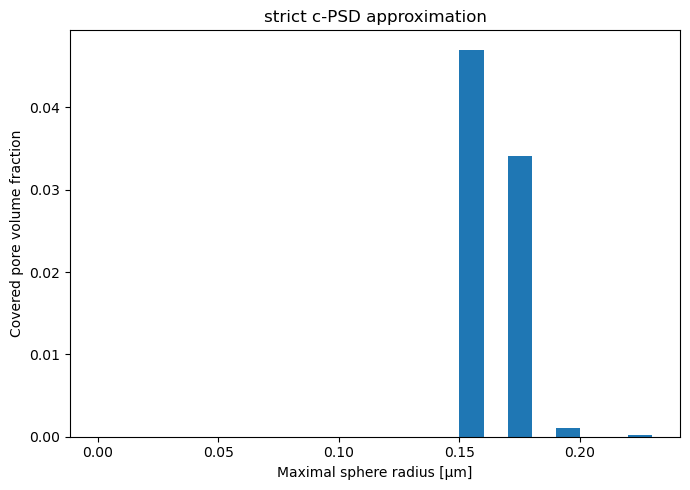

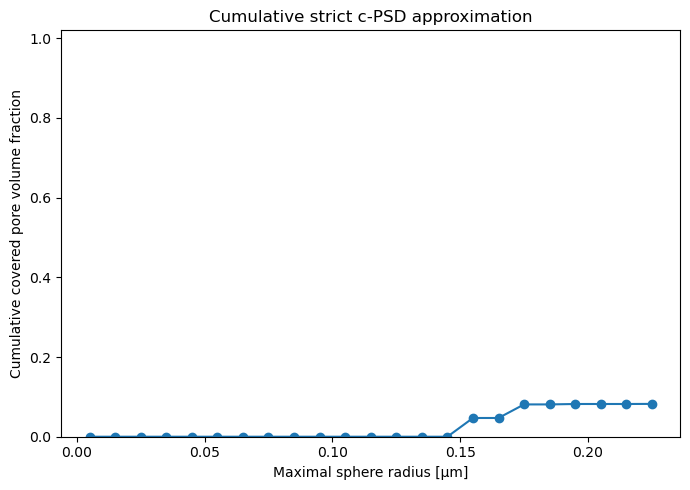

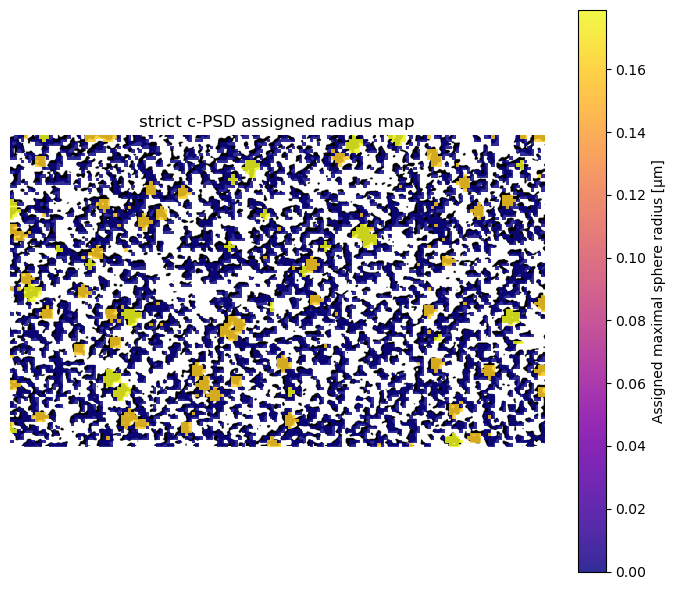

In [14]:
if RUN_STRICT_CPSD and "strict_psd_df" in globals():
    plt.figure(figsize=(7, 5))
    plt.bar(strict_psd_df["radius_um"], strict_psd_df["volume_fraction"], width=RADIUS_BIN_WIDTH_UM, align="center")
    plt.xlabel("Maximal sphere radius [µm]")
    plt.ylabel("Covered pore volume fraction")
    plt.title("strict c-PSD approximation")
    plt.tight_layout()
    plt.savefig(output_dir / "strict_cpsd_radius_distribution.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(strict_psd_df["radius_um"], strict_psd_df["cumulative_volume_fraction"], marker="o")
    plt.xlabel("Maximal sphere radius [µm]")
    plt.ylabel("Cumulative covered pore volume fraction")
    plt.ylim(0, 1.02)
    plt.title("Cumulative strict c-PSD approximation")
    plt.tight_layout()
    plt.savefig(output_dir / "strict_cpsd_cumulative_distribution.png", dpi=200)
    plt.show()

    z_mid_strict = pore_for_edt.shape[0] // 2
    strict_slice = np.where(pore_for_edt[z_mid_strict], assigned_radius_map[z_mid_strict], np.nan)
    plt.figure(figsize=(7, 6))
    plt.imshow(img[min(z_mid_strict * EDT_STRIDE, img.shape[0] - 1)], cmap="gray")
    im = plt.imshow(strict_slice, cmap="plasma", alpha=0.85, extent=(0, img.shape[2], img.shape[1], 0))
    plt.colorbar(im, label="Assigned maximal sphere radius [µm]")
    plt.title("strict c-PSD assigned radius map")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / "strict_cpsd_assigned_radius_map.png", dpi=200)
    plt.show()


## 12. 解釈

距離変換ベースの孔径分布を解釈します。結果は、二値化しきい値、voxel size、画像解像度、前処理条件に強く依存します。


In [15]:
print("=== Interpretation ===")
print(f"平均孔半径: {mean_radius_um:.4f} µm")
print(f"中央値孔半径: {median_radius_um:.4f} µm")
print(f"P10/P50/P90 孔半径: {p10_radius_um:.4f}, {p50_radius_um:.4f}, {p90_radius_um:.4f} µm")
print("この孔径分布は、二値化された3D孔相に基づく距離変換ベースの推定値です。")
print("しきい値、voxel size、画像解像度、前処理条件によって結果は変化します。")
print("特に解像度以下の微細孔や、FIB-SEMで見えないナノフィブリルは評価に反映されません。")


=== Interpretation ===
平均孔半径: 0.0850 µm
中央値孔半径: 0.0800 µm
P10/P50/P90 孔半径: 0.0800, 0.0800, 0.1131 µm
この孔径分布は、二値化された3D孔相に基づく距離変換ベースの推定値です。
しきい値、voxel size、画像解像度、前処理条件によって結果は変化します。
特に解像度以下の微細孔や、FIB-SEMで見えないナノフィブリルは評価に反映されません。
